The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DEEP1b: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:17:59.csv -> trie_pruning_curves/plots/DEEP1b_paper_bound_profile.pdf


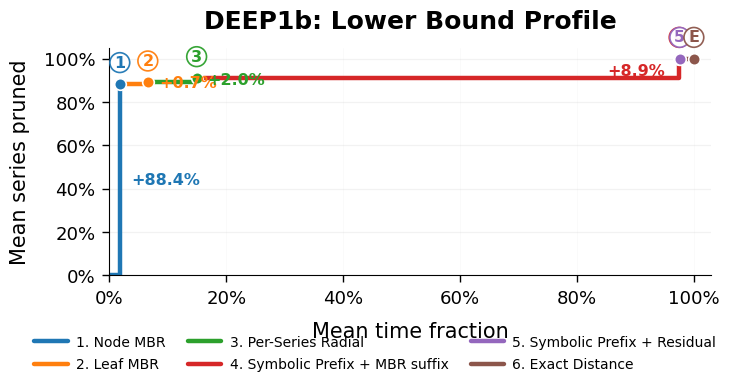

ETHC: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:21:46.csv -> trie_pruning_curves/plots/ETHC_paper_bound_profile.pdf


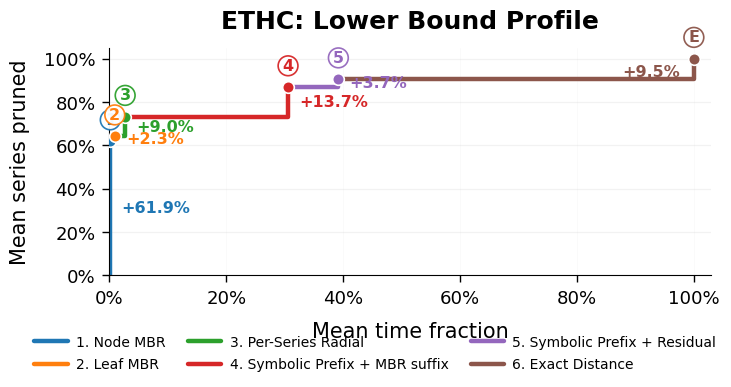

Iquique: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:22:07.csv -> trie_pruning_curves/plots/Iquique_paper_bound_profile.pdf


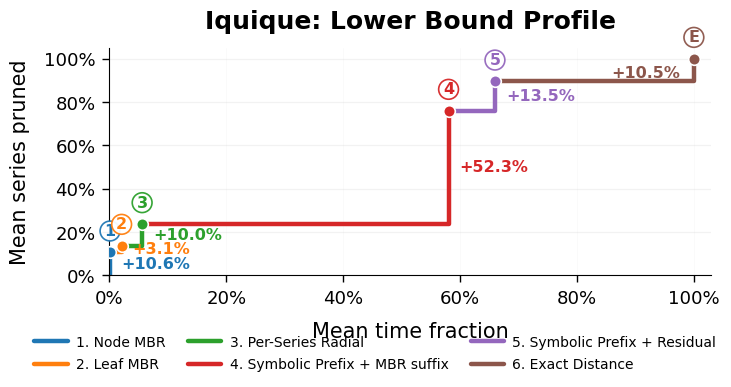

LenDB: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:22:17.csv -> trie_pruning_curves/plots/LenDB_paper_bound_profile.pdf


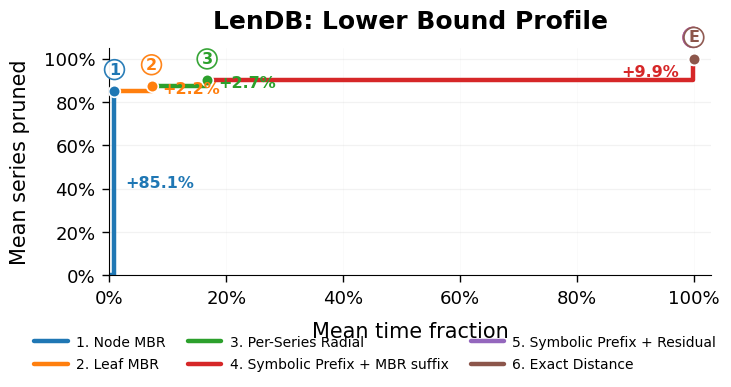

NEIC: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:23:36.csv -> trie_pruning_curves/plots/NEIC_paper_bound_profile.pdf


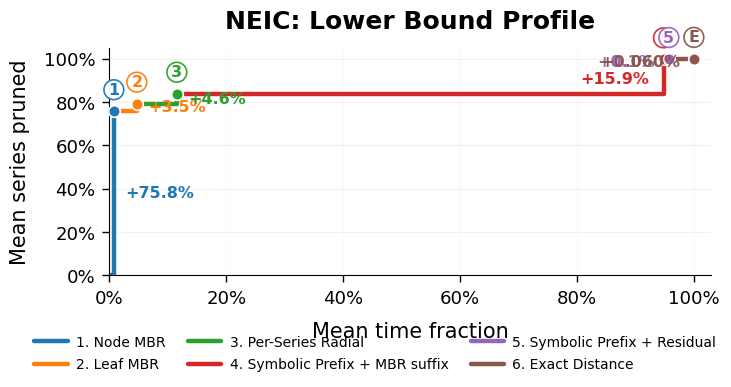

OBS: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:26:33.csv -> trie_pruning_curves/plots/OBS_paper_bound_profile.pdf


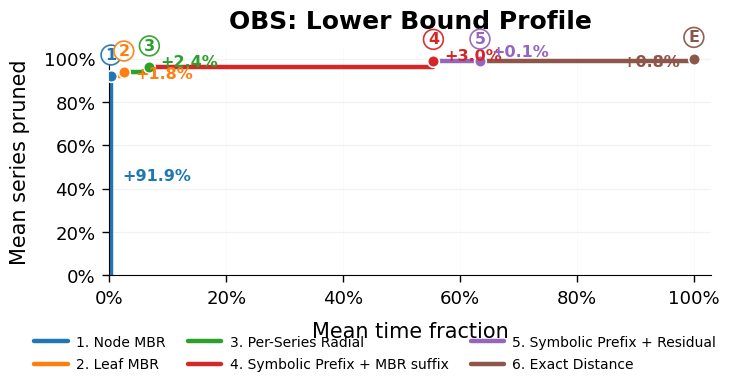

OBST2024: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:29:00.csv -> trie_pruning_curves/plots/OBST2024_paper_bound_profile.pdf


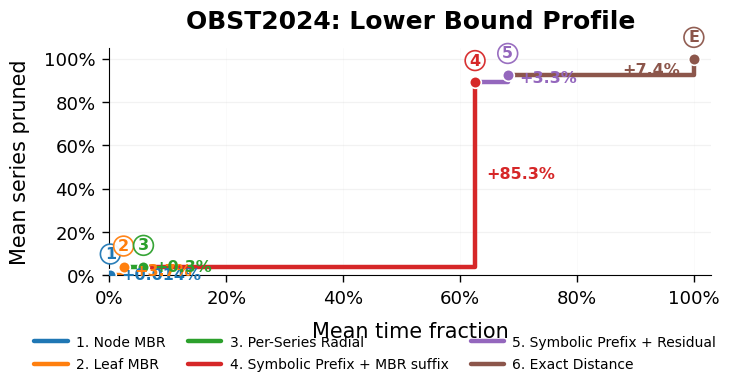

SIFT1b: MESSI_TRIE_PRUNING_CURVE_2026_09_18_11:19:41.csv -> trie_pruning_curves/plots/SIFT1b_paper_bound_profile.pdf


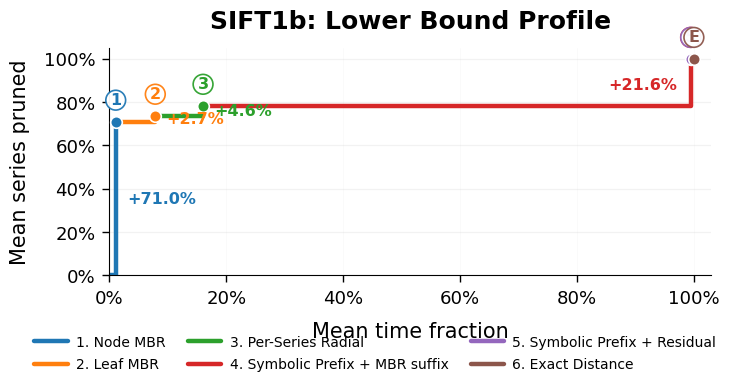

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import csv
import sys
import matplotlib.pyplot as plt

repository = Path.cwd().resolve()
if not (repository / 'scripts').is_dir():
    repository = repository.parent
if not (repository / 'scripts').is_dir():
    raise FileNotFoundError('Run this notebook from the repository root or notebooks/')
if str(repository) not in sys.path:
    sys.path.insert(0, str(repository))

from scripts.plot_trie_pruning_curve import (
    PAPER_REQUIRED_COLUMNS,
    newest_dataset_curve,
    plot_paper_bound_profile,
)

curve_root_candidates = (
    repository / 'results' / 'trie_pruning_curves',
    Path('trie_pruning_curves'),
    repository / 'notebooks' / 'trie_pruning_curves',
)
curve_root = next((path for path in curve_root_candidates if path.is_dir()), None)
if curve_root is None:
    searched = '\n  '.join(str(path) for path in curve_root_candidates)
    raise FileNotFoundError(f'No trie-pruning-curves directory found. Searched:\n  {searched}')

output_directory = curve_root / 'plots'
output_directory.mkdir(parents=True, exist_ok=True)
for dataset_directory in sorted(curve_root.iterdir()):
    if not dataset_directory.is_dir() or dataset_directory.name == 'plots':
        continue
    curve_file = newest_dataset_curve(dataset_directory)
    if curve_file is None:
        continue
    dataset = dataset_directory.name
    with curve_file.open(newline='') as stream:
        fields = set(next(csv.reader(stream), ()))
    output = output_directory / f'{dataset}_paper_bound_profile.pdf'
    fig, _ = plot_paper_bound_profile(
        curve_file, aggregate='mean',
        title=f'{dataset}: Lower Bound Profile', output=output,
    )
    print(f'{dataset}: {curve_file.name} -> {output}')
    plt.show()
    plt.close(fig)